# Lab 2 — Energy-Tracking Projectile
**Name:** Alex Bebb <br>
**Date:** 9/6/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A — Adding Energy Tracking

I will extend my gravity-only projectile simulator from Lab 1 to track
kinetic energy, gravitational potential energy, and total mechanical
energy at each time step.

The energy calculations are:

$$K = \frac{1}{2}m(v_x^2 + v_y^2)$$
<br>
$$U = mgy$$
<br>
$$E_{\mathrm{total}} = K + U$$
<br>
I am taking up as the positive y-direction and setting gravitational potential
energy to zero at the launch height, y = 0. All energies are measured
in joules.

The simulation uses standard Euler: positions are updated using the
old velocities, then velocities are updated using the acceleration

In [2]:
def simulate_projectile_2d(v0, theta_deg, dt, g=9.81, m=1.0):
    """Simulate gravity-only 2-D projectile motion using standard Euler.

    Parameters:
        v0        : initial launch speed (m/s)
        theta_deg : launch angle above horizontal (degrees)
        dt        : time step (s)
        g         : gravitational acceleration magnitude (m/s²)
        m         : projectile mass (kg)

    Returns:
        Lists of time, position components, velocity components,
        kinetic energy, potential energy, and total mechanical energy.
    """

    # Convert the launch angle to radians
    theta_rad = np.radians(theta_deg)

    # Initial velocity components (m/s)
    vx = v0 * np.cos(theta_rad)
    vy = v0 * np.sin(theta_rad)

    # Initial position (m) and time (s)
    x = 0.0
    y = 0.0
    t = 0.0

    # Store the initial time, position, and velocity
    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    # Calculate initial energies (J)
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    # Store the initial energies
    KE_arr = [KE]
    PE_arr = [PE]
    E_total_arr = [E_total]

    # Continue until the first step below ground level
    while y >= 0:
        # Acceleration components (m/s²): gravity only
        ax = 0.0
        ay = -g

        # Standard Euler: update position using OLD velocity
        x = x + vx * dt
        y = y + vy * dt

        # Then update velocity
        vx = vx + ax * dt
        vy = vy + ay * dt

        # Advance time
        t = t + dt

        # Store the updated time, position, and velocity
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

        # Calculate energies from the SAME updated state (J)
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        # Store the updated energies
        KE_arr.append(KE)
        PE_arr.append(PE)
        E_total_arr.append(E_total)

    return (
        t_arr, x_arr, y_arr, vx_arr, vy_arr,
        KE_arr, PE_arr, E_total_arr
    )

In [3]:
# Lab 2 launch conditions
v0 = 30.0          # Initial speed (m/s)
theta_deg = 50.0   # Launch angle above horizontal (degrees)
dt = 0.01         # Time step (s)
g = 9.81          # Gravitational acceleration magnitude (m/s²)
m = 1.0           # Mass (kg)

# Run the simulation and assign its returned lists to variables
(
    t_data, x_data, y_data, vx_data, vy_data,
    KE_data, PE_data, E_total_data
) = simulate_projectile_2d(
    v0=v0,
    theta_deg=theta_deg,
    dt=dt,
    g=g,
    m=m
)

# Check that the simulation ran and stored the initial energies
print(f"Number of stored time points: {len(t_data)}")
print(f"Initial kinetic energy: {KE_data[0]:.2f} J")
print(f"Initial potential energy: {PE_data[0]:.2f} J")
print(f"Initial total energy: {E_total_data[0]:.2f} J")

Number of stored time points: 471
Initial kinetic energy: 450.00 J
Initial potential energy: 0.00 J
Initial total energy: 450.00 J


### Energy versus time

The following plot shows kinetic energy, gravitational potential energy,
and total mechanical energy throughout the gravity-only simulation.

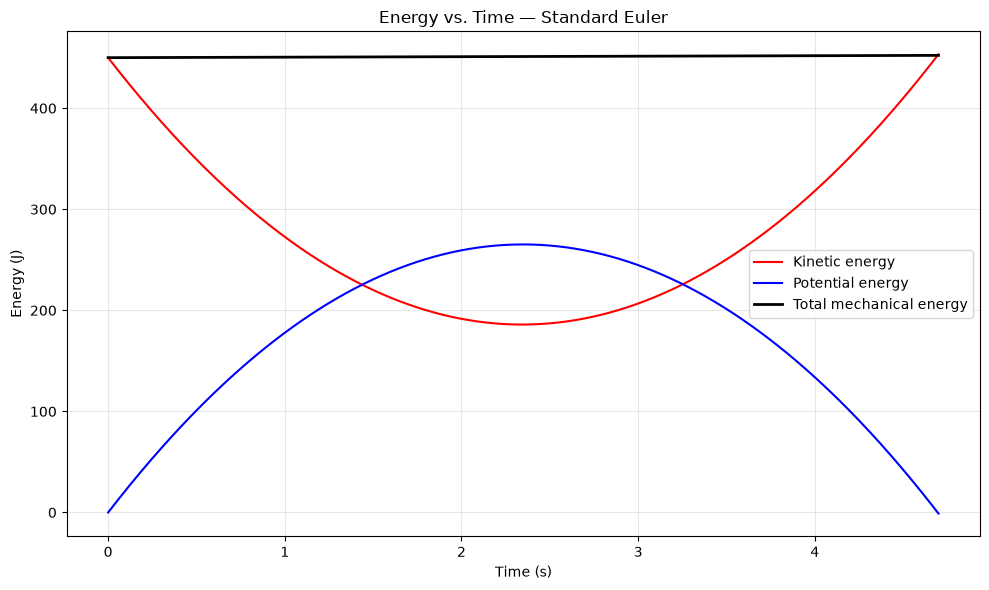

In [4]:
# Create a figure
plt.figure(figsize=(10, 6))

# Plot each energy against the same stored times
plt.plot(t_data, KE_data, label='Kinetic energy', color='red')
plt.plot(t_data, PE_data, label='Potential energy', color='blue')
plt.plot(
    t_data, E_total_data,
    label='Total mechanical energy',
    color='black',
    linewidth=2
)

# Label the axes and give the plot a title
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy vs. Time — Standard Euler')

# Add a legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust spacing and display the plot
plt.tight_layout()
plt.show()

### Energy drift

I calculate energy drift by subtracting the initial total mechanical
energy from the total mechanical energy at each stored time:

$$\Delta E(t) = E_{\mathrm{total}}(t) - E_{\mathrm{total}}(0).$$

Positive drift means the simulation has gained mechanical energy;
negative drift means it has lost mechanical energy.

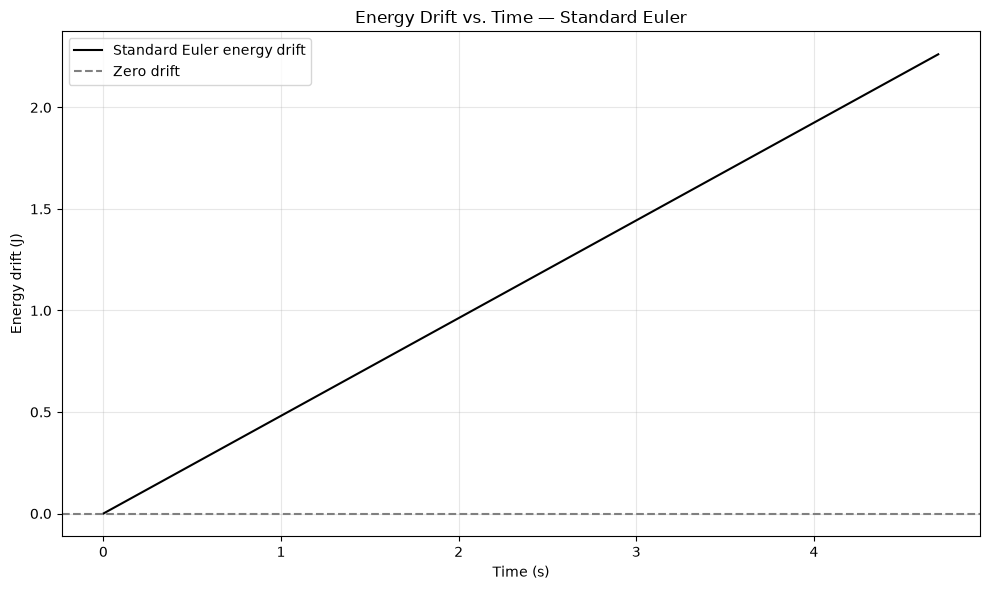

In [5]:
# Convert the total-energy list into a NumPy array
E_total_array = np.array(E_total_data)

# Subtract the initial energy from every stored energy
energy_drift = E_total_array - E_total_array[0]

# Plot energy drift versus time
plt.figure(figsize=(10, 6))
plt.plot(
    t_data, energy_drift,
    color='black',
    label='Standard Euler energy drift'
)

# Reference line showing perfect energy conservation
plt.axhline(
    y=0.0,
    color='gray',
    linestyle='--',
    label='Zero drift'
)

plt.xlabel('Time (s)')
plt.ylabel('Energy drift (J)')
plt.title('Energy Drift vs. Time — Standard Euler')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Initial total mechanical energy (J)
initial_energy = E_total_array[0]

# Largest magnitude of energy drift anywhere in the simulation (J)
max_absolute_drift = np.max(np.abs(energy_drift))

# Express that maximum drift as a percentage of initial energy
max_percentage_drift = (
    max_absolute_drift / abs(initial_energy)
) * 100

# Report the results
print(f"Initial total energy: {initial_energy:.2f} J")
print(f"Maximum absolute energy drift: {max_absolute_drift:.4f} J")
print(f"Maximum percentage energy drift: {max_percentage_drift:.4f}%")

Initial total energy: 450.00 J
Maximum absolute energy drift: 2.2615 J
Maximum percentage energy drift: 0.5026%


### Interpretation

The standard Euler simulation shows a steady, approximately linear
increase in total mechanical energy rather than an accelerating drift.
The maximum absolute drift occurs at the final stored point and is
approximately 2.2615 J, or 0.5026% of the initial 450 J.
Because gravity is the only force and the physical system conserves
mechanical energy, this increase is numerical error from the Euler
method.

## Part B — Euler vs. Euler-Cromer

I will compare standard Euler and Euler-Cromer using the same initial
conditions, gravitational acceleration, mass, and time step.

Standard Euler updates position using the old velocity. Euler-Cromer
updates velocity first, then uses that new velocity to update position.

A single function will select between the two methods so that the
remaining simulation code is shared.

In [7]:
def simulate(method, dt, v0=30.0, theta_deg=50.0, g=9.81, m=1.0):
    """Simulate a gravity-only projectile with energy tracking.

    Parameters:
        method    : 'euler' or 'euler-cromer'
        dt        : time step (s)
        v0        : initial launch speed (m/s)
        theta_deg : launch angle above horizontal (degrees)
        g         : gravitational acceleration magnitude (m/s²)
        m         : projectile mass (kg)

    Returns:
        NumPy arrays of time, position components, velocity components,
        kinetic energy, potential energy, and total mechanical energy.
    """

    # Check that the requested method is recognized
    if method not in ('euler', 'euler-cromer'):
        raise ValueError("method must be 'euler' or 'euler-cromer'")

    # Initial velocity components (m/s)
    theta_rad = np.radians(theta_deg)
    vx = v0 * np.cos(theta_rad)
    vy = v0 * np.sin(theta_rad)

    # Initial position (m) and time (s)
    x = 0.0
    y = 0.0
    t = 0.0

    # Store the initial state
    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    # Initial energies (J)
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    KE_arr = [KE]
    PE_arr = [PE]
    E_total_arr = [E_total]

    while y >= 0:
        # Gravity-only acceleration (m/s²)
        ax = 0.0
        ay = -g

        # Select the integration method
        if method == 'euler':
            # Position uses OLD velocity
            x = x + vx * dt
            y = y + vy * dt

            vx = vx + ax * dt
            vy = vy + ay * dt

        elif method == 'euler-cromer':
            # Update velocity FIRST
            vx = vx + ax * dt
            vy = vy + ay * dt

            # Position uses NEW velocity
            x = x + vx * dt
            y = y + vy * dt

        # Advance time
        t = t + dt

        # Store the updated state
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

        # Calculate and store energies for the updated state (J)
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        KE_arr.append(KE)
        PE_arr.append(PE)
        E_total_arr.append(E_total)

    # Return histories as NumPy arrays for later calculations
    return (
        np.array(t_arr),
        np.array(x_arr),
        np.array(y_arr),
        np.array(vx_arr),
        np.array(vy_arr),
        np.array(KE_arr),
        np.array(PE_arr),
        np.array(E_total_arr)
    )

In [8]:
# Shared launch conditions for both methods
v0_b = 30.0          # Initial speed (m/s)
theta_b = 50.0       # Launch angle (degrees)
dt_b = 0.01          # Time step (s)
g_b = 9.81           # Gravitational acceleration magnitude (m/s²)
m_b = 1.0            # Mass (kg)

# Run standard Euler
(
    t_e, x_e, y_e, vx_e, vy_e,
    KE_e, PE_e, E_total_e
) = simulate(
    method='euler',
    dt=dt_b,
    v0=v0_b,
    theta_deg=theta_b,
    g=g_b,
    m=m_b
)

# Run Euler-Cromer
(
    t_ec, x_ec, y_ec, vx_ec, vy_ec,
    KE_ec, PE_ec, E_total_ec
) = simulate(
    method='euler-cromer',
    dt=dt_b,
    v0=v0_b,
    theta_deg=theta_b,
    g=g_b,
    m=m_b
)

# Confirm that both simulations completed
print(f"Euler: {len(t_e)} stored time points")
print(f"Euler-Cromer: {len(t_ec)} stored time points")

print(f"Euler initial energy: {E_total_e[0]:.2f} J")
print(f"Euler-Cromer initial energy: {E_total_ec[0]:.2f} J")

Euler: 471 stored time points
Euler-Cromer: 469 stored time points
Euler initial energy: 450.00 J
Euler-Cromer initial energy: 450.00 J


### Comparing energy drift

For each method, I subtract its initial total energy from its total
energy at every stored time. I plot both drift curves on the same axes
to compare the direction and size of their numerical errors.

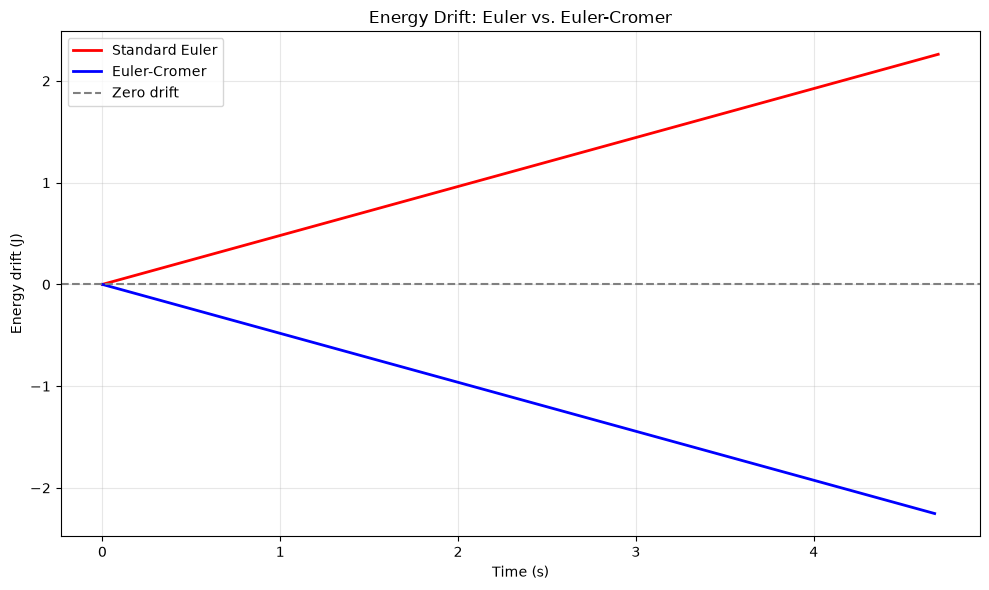

In [9]:
# Calculate energy drift for each method (J)
drift_e = E_total_e - E_total_e[0]
drift_ec = E_total_ec - E_total_ec[0]

# Plot each method against its own stored times
plt.figure(figsize=(10, 6))

plt.plot(
    t_e, drift_e,
    color='red',
    label='Standard Euler',
    linewidth=2
)

plt.plot(
    t_ec, drift_ec,
    color='blue',
    label='Euler-Cromer',
    linewidth=2
)

# Reference line for perfect energy conservation
plt.axhline(
    y=0.0,
    color='gray',
    linestyle='--',
    label='Zero drift'
)

plt.xlabel('Time (s)')
plt.ylabel('Energy drift (J)')
plt.title('Energy Drift: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Trajectory comparison

I plot vertical position versus horizontal position for both methods
using identical launch conditions.

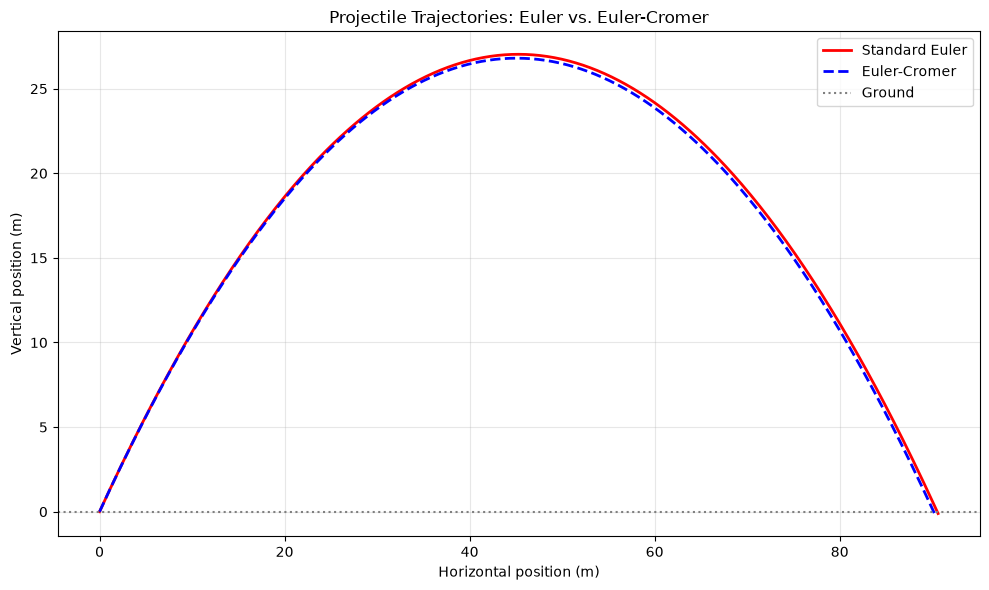

In [10]:
# Compare the two trajectories
plt.figure(figsize=(10, 6))

plt.plot(
    x_e, y_e,
    color='red',
    linestyle='-',
    label='Standard Euler',
    linewidth=2
)

plt.plot(
    x_ec, y_ec,
    color='blue',
    linestyle='--',
    label='Euler-Cromer',
    linewidth=2
)

# Show ground level
plt.axhline(y=0.0, color='gray', linestyle=':', label='Ground')

plt.xlabel('Horizontal position (m)')
plt.ylabel('Vertical position (m)')
plt.title('Projectile Trajectories: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Landing-range comparison

Each simulation stores its first point below ground. To estimate the
horizontal position at y = 0, I linearly interpolate between the last
point at or above ground and the first point below ground.

In [11]:
# Euler: fraction of the final step needed to reach y = 0
fraction_e = y_e[-2] / (y_e[-2] - y_e[-1])

# Estimate horizontal position at that fraction of the step
range_e = x_e[-2] + fraction_e * (x_e[-1] - x_e[-2])

# Euler-Cromer: repeat the same calculation
fraction_ec = y_ec[-2] / (y_ec[-2] - y_ec[-1])
range_ec = x_ec[-2] + fraction_ec * (x_ec[-1] - x_ec[-2])

# Difference between the estimated landing ranges
range_difference = range_e - range_ec

print(f"Euler estimated landing range: {range_e:.4f} m")
print(f"Euler-Cromer estimated landing range: {range_ec:.4f} m")
print(f"Euler minus Euler-Cromer range: {range_difference:.4f} m")

Euler estimated landing range: 90.5421 m
Euler-Cromer estimated landing range: 90.1564 m
Euler minus Euler-Cromer range: 0.3857 m


### Interpretation

The two trajectories nearly overlap, but standard Euler predicts a slightly higher trajectory and a landing range approximately 0.386 m greater than Euler-Cromer. Standard Euler uses the old velocity to update position, overestimating the height, while Euler-Cromer uses the updated velocity, underestimating the height. Under constant gravitational acceleration, both methods calculate velocity exactly at the stored times, so their energy errors come entirely from their position errors through gravitational potential energy. Consequently, their energy drifts are linear and equal in magnitude with opposite signs at matching times, consistent with the lesson’s clarification that Euler-Cromer does not conserve energy more accurately for this particular system.


## Part C — Convergence Study

I will run both integration methods with progressively smaller time
steps and measure the maximum absolute energy drift during each
simulation.

Each time step is half the previous one. This lets me investigate how
the size of the numerical error depends on the time step.

In [12]:
# Time steps to test (s)
dt_values = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])

# Lists that will store one maximum drift per simulation
max_drifts_e = []
max_drifts_ec = []

# Run both methods at every time step
for dt_value in dt_values:

    # Standard Euler
    results_e = simulate(
        method='euler',
        dt=dt_value,
        v0=v0_b,
        theta_deg=theta_b,
        g=g_b,
        m=m_b
    )

    energies_e = results_e[-1]
    drift_e_run = energies_e - energies_e[0]
    max_drifts_e.append(np.max(np.abs(drift_e_run)))

    # Euler-Cromer
    results_ec = simulate(
        method='euler-cromer',
        dt=dt_value,
        v0=v0_b,
        theta_deg=theta_b,
        g=g_b,
        m=m_b
    )

    energies_ec = results_ec[-1]
    drift_ec_run = energies_ec - energies_ec[0]
    max_drifts_ec.append(np.max(np.abs(drift_ec_run)))

# Convert the collected maximum drifts to NumPy arrays
max_drifts_e = np.array(max_drifts_e)
max_drifts_ec = np.array(max_drifts_ec)

# Display a comparison table
print(f"{'dt (s)':>10} {'Euler max drift (J)':>22} {'E-C max drift (J)':>22}")

for i in range(len(dt_values)):
    print(
        f"{dt_values[i]:10.5f} "
        f"{max_drifts_e[i]:22.6f} "
        f"{max_drifts_ec[i]:22.6f}"
    )

    dt (s)    Euler max drift (J)      E-C max drift (J)
   0.10000              23.096664              22.134303
   0.05000              11.428037              11.187447
   0.02500               5.683945               5.623797
   0.01250               2.826935               2.811899
   0.00625               1.411588               1.407829


### Convergence plot

I plot maximum absolute energy drift against time step using logarithmic
scales on both axes. If the error is proportional to the time step
raised to a power p, the points should approximately follow a straight
line with slope p.

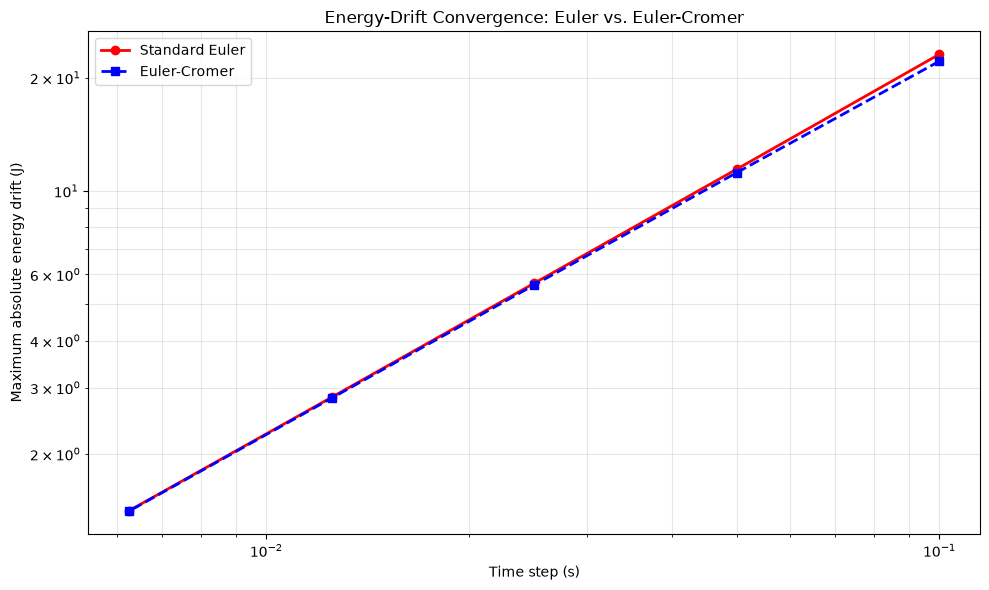

In [13]:
# Plot maximum energy drift against time step on logarithmic axes
plt.figure(figsize=(10, 6))

plt.loglog(
    dt_values, max_drifts_e,
    color='red',
    marker='o',
    linestyle='-',
    label='Standard Euler',
    linewidth=2
)

plt.loglog(
    dt_values, max_drifts_ec,
    color='blue',
    marker='s',
    linestyle='--',
    label='Euler-Cromer',
    linewidth=2
)

plt.xlabel('Time step (s)')
plt.ylabel('Maximum absolute energy drift (J)')
plt.title('Energy-Drift Convergence: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Express the quantities relative to reference units before taking logs
dt_reference = 1.0       # 1 second
energy_reference = 1.0   # 1 joule

log_dt = np.log(dt_values / dt_reference)
log_drift_e = np.log(max_drifts_e / energy_reference)
log_drift_ec = np.log(max_drifts_ec / energy_reference)

# Fit a straight line to each set of logarithmic data
fit_e = np.polyfit(log_dt, log_drift_e, 1)
fit_ec = np.polyfit(log_dt, log_drift_ec, 1)

# The first returned coefficient is the slope
slope_e = fit_e[0]
slope_ec = fit_ec[0]

print(f"Euler estimated order: p = {slope_e:.3f}")
print(f"Euler-Cromer estimated order: p = {slope_ec:.3f}")

Euler estimated order: p = 1.008
Euler-Cromer estimated order: p = 0.994


### Choosing a time step for a 0.01% energy tolerance

Using the approximately first-order convergence observed above, I
estimate a smaller time step from the finest tested step and its
measured maximum energy drift. I then run both methods at the estimated
step size to check whether their maximum percentage drifts are below
0.01%.

In [15]:
# Desired maximum energy drift, expressed as a percentage
target_percent = 0.01

# Initial energy for our shared launch conditions (J)
initial_energy_c = 0.5 * m_b * v0_b**2

# Convert the percentage tolerance into an energy tolerance (J)
allowed_drift = (target_percent / 100) * initial_energy_c

# Use the smallest step from our convergence study
finest_dt = dt_values[-1]

# Use the larger of the two measured errors at that step
reference_drift = max(max_drifts_e[-1], max_drifts_ec[-1])

# First-order estimate, with a 10% reduction for a margin
dt_candidate = 0.9 * finest_dt * (allowed_drift / reference_drift)

print(f"Allowed maximum energy drift: {allowed_drift:.4f} J")
print(f"Candidate time step: {dt_candidate:.8f} s")

# Run both methods at the candidate step and check the actual errors
for method_name in ('euler', 'euler-cromer'):
    results = simulate(
        method=method_name,
        dt=dt_candidate,
        v0=v0_b,
        theta_deg=theta_b,
        g=g_b,
        m=m_b
    )

    energies = results[-1]
    maximum_drift = np.max(np.abs(energies - energies[0]))
    percentage_drift = maximum_drift / abs(energies[0]) * 100

    meets_target = percentage_drift <= target_percent

    print(f"\nMethod: {method_name}")
    print(f"Maximum absolute drift: {maximum_drift:.6f} J")
    print(f"Maximum percentage drift: {percentage_drift:.6f}%")
    print(f"Meets 0.01% target: {meets_target}")

Allowed maximum energy drift: 0.0450 J
Candidate time step: 0.00017932 s

Method: euler
Maximum absolute drift: 0.040430 J
Maximum percentage drift: 0.008984%
Meets 0.01% target: True

Method: euler-cromer
Maximum absolute drift: 0.040427 J
Maximum percentage drift: 0.008984%
Meets 0.01% target: True


### Interpretation

The measured convergence slopes are 1.008 for standard Euler and 0.994 for Euler-Cromer. Both are close to 1, consistent with the lesson’s prediction of first-order convergence: halving the time step approximately halves the maximum energy drift.

The convergence curves nearly overlap, although Euler-Cromer has slightly smaller maximum drift at each tested step size. This difference reflects the simulations ending at different times; at matching times, the energy errors have equal magnitudes and opposite signs. Therefore, these results do not show that Euler-Cromer conserves energy more accurately for a projectile under uniform gravity.

For a maximum energy drift below 0.01%, I would choose standard Euler with a time step of approximately 0.00017932 s, although either method meets the requirement. At this step size, the measured maximum drift was 0.040430 J for Euler and 0.040427 J for Euler-Cromer, both approximately 0.008984% of the initial 450 J. Both are below the allowed drift of 0.0450 J.


## Bonus — Drag and Physical Energy Loss

I add quadratic drag to the projectile simulation and use Euler-Cromer
to update the motion. I retain the previous launch conditions and use
a drag coefficient divided by mass of 0.0046 inverse meters.

The drag-force components are

$$F_{\mathrm{drag},x}=-b|\mathbf{v}|v_x,$$

$$F_{\mathrm{drag},y}=-b|\mathbf{v}|v_y.$$

I estimate the work done by drag by summing its power over time:

$$W_{\mathrm{drag}}\approx
\sum \left(F_{\mathrm{drag},x}v_x+
F_{\mathrm{drag},y}v_y\right)\Delta t.$$

Work done by drag is negative. The positive mechanical energy lost
should approximately equal the negative of that work:

$$E_{\mathrm{initial}}-E_{\mathrm{final}}\approx-W_{\mathrm{drag}}.$$

In [16]:
def simulate_drag_energy(
    dt, v0=30.0, theta_deg=50.0,
    g=9.81, m=1.0, b_over_m=0.0046
):
    """Simulate a projectile with quadratic drag using Euler-Cromer.

    Inputs use SI units, except theta_deg, which is in degrees.
    Returns arrays of time, total mechanical energy, and cumulative
    work done by drag.
    """

    # Initial conditions
    theta_rad = np.radians(theta_deg)
    vx = v0 * np.cos(theta_rad)
    vy = v0 * np.sin(theta_rad)

    x = 0.0
    y = 0.0
    t = 0.0

    # Recover b from the supplied ratio b/m
    b = m * b_over_m

    # Initial energy (J) and accumulated drag work (J)
    energy = 0.5 * m * (vx**2 + vy**2) + m * g * y
    work_drag = 0.0

    t_history = [t]
    energy_history = [energy]
    work_history = [work_drag]

    while y >= 0:
        # Speed and drag force at the START of this step
        speed = np.sqrt(vx**2 + vy**2)
        force_drag_x = -b * speed * vx
        force_drag_y = -b * speed * vy

        # Drag power: force dotted with velocity (W)
        power_drag = force_drag_x * vx + force_drag_y * vy

        # Approximate drag work during this step (J)
        work_drag = work_drag + power_drag * dt

        # Acceleration from drag and gravity (m/s²)
        ax = force_drag_x / m
        ay = -g + force_drag_y / m

        # Euler-Cromer: velocity first
        vx = vx + ax * dt
        vy = vy + ay * dt

        # Position uses the updated velocity
        x = x + vx * dt
        y = y + vy * dt
        t = t + dt

        # Energy at the updated state (J)
        energy = 0.5 * m * (vx**2 + vy**2) + m * g * y

        # Store time, energy, and accumulated work
        t_history.append(t)
        energy_history.append(energy)
        work_history.append(work_drag)

    return (
        np.array(t_history),
        np.array(energy_history),
        np.array(work_history)
    )

In [17]:
def simulate_drag_energy(
    dt, v0=30.0, theta_deg=50.0,
    g=9.81, m=1.0, b_over_m=0.0046
):
    """Simulate a projectile with quadratic drag using Euler-Cromer.

    Inputs use SI units, except theta_deg, which is in degrees.
    Returns arrays of time, total mechanical energy, and cumulative
    work done by drag.
    """

    # Initial conditions
    theta_rad = np.radians(theta_deg)
    vx = v0 * np.cos(theta_rad)
    vy = v0 * np.sin(theta_rad)

    x = 0.0
    y = 0.0
    t = 0.0

    # Recover b from the supplied ratio b/m
    b = m * b_over_m

    # Initial energy (J) and accumulated drag work (J)
    energy = 0.5 * m * (vx**2 + vy**2) + m * g * y
    work_drag = 0.0

    t_history = [t]
    energy_history = [energy]
    work_history = [work_drag]

    while y >= 0:
        # Speed and drag force at the START of this step
        speed = np.sqrt(vx**2 + vy**2)
        force_drag_x = -b * speed * vx
        force_drag_y = -b * speed * vy

        # Drag power: force dotted with velocity (W)
        power_drag = force_drag_x * vx + force_drag_y * vy

        # Approximate drag work during this step (J)
        work_drag = work_drag + power_drag * dt

        # Acceleration from drag and gravity (m/s²)
        ax = force_drag_x / m
        ay = -g + force_drag_y / m

        # Euler-Cromer: velocity first
        vx = vx + ax * dt
        vy = vy + ay * dt

        # Position uses the updated velocity
        x = x + vx * dt
        y = y + vy * dt
        t = t + dt

        # Energy at the updated state (J)
        energy = 0.5 * m * (vx**2 + vy**2) + m * g * y

        # Store time, energy, and accumulated work
        t_history.append(t)
        energy_history.append(energy)
        work_history.append(work_drag)

    return (
        np.array(t_history),
        np.array(energy_history),
        np.array(work_history)
    )

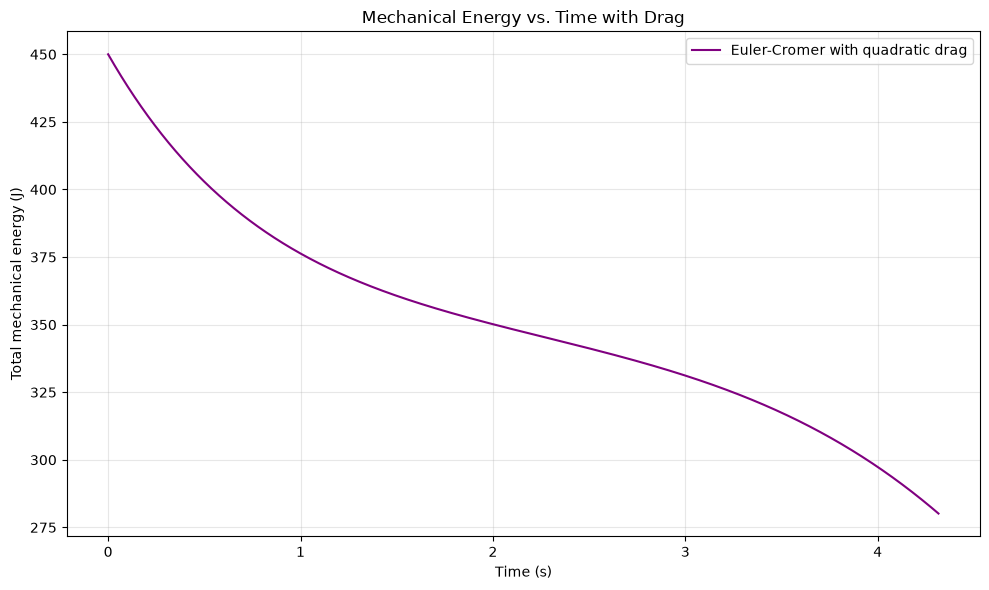

Energy decreases at every step: True


In [18]:
# Bonus parameters
dt_bonus = 0.001       # Time step (s)
b_over_m_bonus = 0.0046  # Drag coefficient divided by mass (1/m)

# Run the simulation
t_drag, E_drag, W_drag = simulate_drag_energy(
    dt=dt_bonus,
    v0=v0_b,
    theta_deg=theta_b,
    g=g_b,
    m=m_b,
    b_over_m=b_over_m_bonus
)

# Plot total mechanical energy
plt.figure(figsize=(10, 6))
plt.plot(
    t_drag, E_drag,
    color='purple',
    label='Euler-Cromer with quadratic drag'
)

plt.xlabel('Time (s)')
plt.ylabel('Total mechanical energy (J)')
plt.title('Mechanical Energy vs. Time with Drag')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check whether energy decreases at every stored step
energy_changes = np.diff(E_drag)
decreases_every_step = np.all(energy_changes < 0)

print(f"Energy decreases at every step: {decreases_every_step}")

### Checking the work–energy theorem

I compare the positive mechanical energy lost with the negative of the
work done by drag. Their difference measures the mismatch between the
numerical energy change and the estimated drag work.

I repeat the calculation with half the time step to check whether this
mismatch decreases.

Initial mechanical energy: 450.000000 J
Final mechanical energy: 280.129153 J
Mechanical energy lost: 169.870847 J
Work done by drag: -169.671751 J
Negative of drag work: 169.671751 J
Absolute mismatch: 0.199096 J
Mismatch relative to drag-work magnitude: 0.117342%


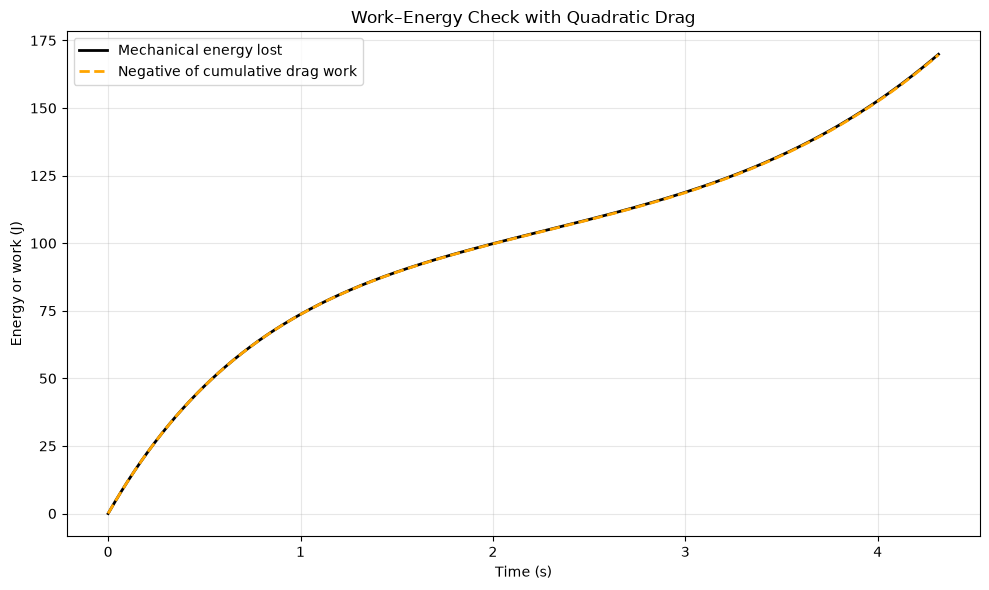

In [19]:
# Positive mechanical energy lost (J)
energy_lost = E_drag[0] - E_drag[-1]

# Work done BY drag is negative; its negative is positive
work_by_drag = W_drag[-1]
work_against_drag = -work_by_drag

# Difference between the two positive quantities
mismatch = abs(energy_lost - work_against_drag)
mismatch_percent = mismatch / abs(work_against_drag) * 100

print(f"Initial mechanical energy: {E_drag[0]:.6f} J")
print(f"Final mechanical energy: {E_drag[-1]:.6f} J")
print(f"Mechanical energy lost: {energy_lost:.6f} J")
print(f"Work done by drag: {work_by_drag:.6f} J")
print(f"Negative of drag work: {work_against_drag:.6f} J")
print(f"Absolute mismatch: {mismatch:.6f} J")
print(f"Mismatch relative to drag-work magnitude: {mismatch_percent:.6f}%")

# Visual comparison over the whole simulation
plt.figure(figsize=(10, 6))

plt.plot(
    t_drag, E_drag[0] - E_drag,
    color='black',
    label='Mechanical energy lost',
    linewidth=2
)

plt.plot(
    t_drag, -W_drag,
    color='orange',
    linestyle='--',
    label='Negative of cumulative drag work',
    linewidth=2
)

plt.xlabel('Time (s)')
plt.ylabel('Energy or work (J)')
plt.title('Work–Energy Check with Quadratic Drag')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Repeat with half the original bonus time step
dt_bonus_fine = dt_bonus / 2

t_drag_fine, E_drag_fine, W_drag_fine = simulate_drag_energy(
    dt=dt_bonus_fine,
    v0=v0_b,
    theta_deg=theta_b,
    g=g_b,
    m=m_b,
    b_over_m=b_over_m_bonus
)

# Calculate the same work–energy mismatch
energy_lost_fine = E_drag_fine[0] - E_drag_fine[-1]
work_against_drag_fine = -W_drag_fine[-1]

mismatch_fine = abs(energy_lost_fine - work_against_drag_fine)
mismatch_percent_fine = (
    mismatch_fine / abs(work_against_drag_fine) * 100
)

print(f"Original time step: {dt_bonus:.6f} s")
print(f"Original absolute mismatch: {mismatch:.6f} J")
print(f"Original relative mismatch: {mismatch_percent:.6f}%")

print(f"\nSmaller time step: {dt_bonus_fine:.6f} s")
print(f"Smaller-step absolute mismatch: {mismatch_fine:.6f} J")
print(f"Smaller-step relative mismatch: {mismatch_percent_fine:.6f}%")

print(f"\nMismatch decreased: {mismatch_fine < mismatch}")

Original time step: 0.001000 s
Original absolute mismatch: 0.199096 J
Original relative mismatch: 0.117342%

Smaller time step: 0.000500 s
Smaller-step absolute mismatch: 0.099571 J
Smaller-step relative mismatch: 0.058669%

Mismatch decreased: True
